# Fortelny and Bock 2020

One frozen result from
[Fortelny and Bock, 2020](https://doi.org/10.1186/s13059-020-02100-5):
on simulated data with a single planted hidden node, learned node
weights identify that node.

This page uses `kpnn2` primitives in ordinary PyTorch. It does not
run their TensorFlow program, and it is not their TCR or atlas
analyses.

**Claim.** In their SIM1 demo (Figure 3a: one predictive hidden
node, no redundancy), `nodeX` is the unique planted signal. After
training, 0–1-scaled hidden-node weights put `nodeX` at 1 and
the 100 decoys near 0.

**Not claimed.** Matching their TensorFlow run, dropout schedule,
90 replicates, or any real scRNA-seq figure.


## Setup

SIM1 lives in gitignored `.literature-data/fortelny-bock-2020/`
(see `docs/literature/README.md`). Docs CI does not download it
and does not re-run this notebook.


In [ ]:
import hashlib
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from matplotlib_inline.backend_inline import (
    set_matplotlib_formats,
)
from torch import nn

import kpnn2

print("kpnn2", kpnn2.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

set_matplotlib_formats(
    "svg",
    bbox_inches=None,
)
_FONT_SIZE = 6
_plot_rc = {
    "font.size": _FONT_SIZE,
    "axes.titlesize": _FONT_SIZE,
    "axes.labelsize": _FONT_SIZE,
    "xtick.labelsize": _FONT_SIZE,
    "ytick.labelsize": _FONT_SIZE,
    "legend.fontsize": _FONT_SIZE,
    "legend.title_fontsize": _FONT_SIZE,
    "lines.linewidth": 1.0,
    "font.family": "Liberation Sans",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black",
    "axes.grid": False,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "savefig.facecolor": "none",
    "savefig.edgecolor": "none",
    "svg.fonttype": "none",
}
plt.rcParams.update(_plot_rc)

_CHECKSUMS = {
    "SIM1_ClassLabels.csv": (
        "692dbfceab964b977fc521724e0c549e26e1f29b1f17e79acb6234d2fb5e1de8"
    ),
    "SIM1_Data.csv": (
        "eb6d8426d18f9bcbf26d38942343d0e02446904f4be33c07446cbd73e4b4291f"
    ),
    "SIM1_Edgelist.csv": (
        "3fb7bd7a634665d0b8162c6e7280da365b358d7ab9fbc002066b270a7f863ac7"
    ),
}


def _data_dir() -> Path:
    env = os.environ.get("KPNN2_LITERATURE_DATA")
    if env:
        path = Path(env) / "fortelny-bock-2020"
    else:
        path = None
        here = Path.cwd().resolve()
        for candidate in [here, *here.parents]:
            hit = candidate / ".literature-data" / "fortelny-bock-2020"
            if (hit / "SIM1_Edgelist.csv").exists():
                path = hit
                break
        if path is None:
            raise FileNotFoundError(
                "SIM1 files not found. Download them "
                "into .literature-data/fortelny-bock-2020/ "
                "or set KPNN2_LITERATURE_DATA."
            )
    for name, digest in _CHECKSUMS.items():
        payload = hashlib.sha256((path / name).read_bytes()).hexdigest()
        if payload != digest:
            raise ValueError(f"{name} checksum mismatch")
    return path


DATA = _data_dir()
print("data", DATA)

kpnn2 0.2.0
data /home/thomas/Documents/PhD/projects/KPNN/kpnn2/.literature-data/fortelny-bock-2020


## Graph

Their edgelist is `parent`/`child` in the biological cascade
(receptor toward genes). Training reverses it: genes are inputs,
`output` is the class node. `kpnn2.parse_layered()` reads
`source`/`target` in that computation direction.


In [ ]:
def _node_name(raw: str) -> str:
    raw = str(raw).strip()
    if raw.endswith("_gene"):
        return raw[: -len("_gene")]
    return raw


raw_edges = pd.read_csv(DATA / "SIM1_Edgelist.csv")
edges = pd.DataFrame(
    {
        "source": raw_edges["child"].map(_node_name),
        "target": raw_edges["parent"].map(_node_name),
    }
)
expr = pd.read_csv(
    DATA / "SIM1_Data.csv",
    index_col=0,
)
labels = pd.read_csv(DATA / "SIM1_ClassLabels.csv")
gene_nodes = sorted(set(edges["source"]) - set(edges["target"]))
missing = [name for name in gene_nodes if name not in expr.index]
edges = edges[~edges["source"].isin(missing) & ~edges["target"].isin(missing)]
spec = kpnn2.parse_layered(edges)
print("dropped input names", len(missing))
print("layer_dims", spec.layer_dims)
print("n_skips", len(spec.skips))
print("output_nodes", spec.output_nodes)
print("nodeX in hidden", "nodeX" in spec.hidden_nodes)
assert spec.output_nodes == ("output",)
assert "nodeX" in spec.hidden_nodes
assert spec.layer_dims[-1] == 1

dropped input names 12
layer_dims (3504, 101, 1)
n_skips 0
output_nodes ('output',)
nodeX in hidden True


SIM1 is a two-hop DAG: 3,504 genes (after dropping 12 CRISPR
library names that are not in the matrix) into 101 hidden nodes
into one output. `nodeX` is planted; `b1`…`b100` are matched
decoys (37 genes each).


## Expression

Methods: log(TPM + 1), then 0–1 scale per gene on the training
split. 2,000 cells, balanced classes, 60/20/20 split, seed 42.


In [ ]:
counts = expr.loc[list(spec.input_nodes)].T.astype(np.float64)
lib = counts.sum(axis=1).clip(lower=1.0)
x_df = np.log1p(counts.div(lib, axis=0) * 1e6)
y = (
    labels.set_index("barcode")
    .loc[x_df.index, "output"]
    .astype(np.float32)
    .to_numpy()
)
n = len(x_df)
perm = np.random.permutation(n)
n_train = int(0.6 * n)
n_val = int(0.2 * n)
train_i = perm[:n_train]
val_i = perm[n_train : n_train + n_val]
test_i = perm[n_train + n_val :]
x_train = x_df.iloc[train_i]
x_val = x_df.iloc[val_i]
x_test = x_df.iloc[test_i]
y_train = y[train_i]
y_val = y[val_i]
y_test = y[test_i]
lo = x_train.min(axis=0)
span = (x_train.max(axis=0) - lo).replace(0, 1.0)


def _scale(frame: pd.DataFrame) -> pd.DataFrame:
    return (frame - lo) / span


x_train = _scale(x_train)
x_val = _scale(x_val)
x_test = _scale(x_test)
xt = kpnn2.align_inputs(x_train, spec)
xv = kpnn2.align_inputs(x_val, spec)
xs = kpnn2.align_inputs(x_test, spec)
yt = torch.tensor(y_train).view(-1, 1)
yv = torch.tensor(y_val).view(-1, 1)
ys = torch.tensor(y_test).view(-1, 1)
print("X train", tuple(xt.shape), "pos", float(y_train.mean()))

X train (1200, 3504) pos 0.48750001192092896


## Train

One `MaskedLinear` per hop. Sigmoid on the hidden hop, as in
their Methods. Binary cross-entropy on logits. Adam, learning
rate 0.05. An L1 penalty on **live output-hop weights** shrinks
unused hidden units (Figure 3a has one predictive node; decoys
should not keep outgoing weight). That is not their `lambda=0.2`
on every live edge: `MaskedLinear` still stores masked-out
entries, so we regularize only `weight * mask` on the last hop.
Early stopping on validation loss. Node weights are then scaled
to `[0, 1]`, as in their Methods.


In [ ]:
def _roc_auc(y_true, scores) -> float:
    y_true = np.asarray(y_true).ravel()
    scores = np.asarray(scores).ravel()
    n_pos = int((y_true == 1).sum())
    n_neg = int((y_true == 0).sum())
    order = np.argsort(scores)
    ranks = np.empty_like(
        order,
        dtype=np.float64,
    )
    ranks[order] = np.arange(1, len(scores) + 1)
    sum_pos = ranks[y_true == 1].sum()
    return float((sum_pos - n_pos * (n_pos + 1) / 2.0) / (n_pos * n_neg))


class Net(nn.Module):
    def __init__(self, spec: kpnn2.LayeredSpec):
        super().__init__()
        self.spec = spec
        self.hops = nn.ModuleList(
            [kpnn2.MaskedLinear(hop.mask) for hop in spec.hops]
        )

    def forward(
        self,
        x: torch.Tensor,
        *,
        return_saved: bool = False,
    ):
        saved = {0: x}
        hidden = x
        last = len(self.hops) - 1
        for index, hop in enumerate(self.spec.hops):
            sources = kpnn2.gather_hop_inputs(
                saved,
                hop,
            )
            hidden = self.hops[index](sources)
            if index < last:
                hidden = torch.sigmoid(hidden)
            saved[hop.target_layer] = hidden
        if return_saved:
            return hidden, saved
        return hidden


def _output_live_l1(module: Net) -> torch.Tensor:
    hop = module.hops[-1]
    live = hop.parametrizations.weight.original * hop.mask
    return live.abs().sum()


model = Net(spec)
opt = torch.optim.Adam(
    model.parameters(),
    lr=0.05,
)
output_l1 = 0.01
best_val = float("inf")
best_state = None
patience = 0
history = []
for epoch in range(500):
    model.train()
    opt.zero_grad()
    logits = model(xt)
    loss = F.binary_cross_entropy_with_logits(
        logits,
        yt,
    ) + output_l1 * _output_live_l1(model)
    loss.backward()
    opt.step()
    model.eval()
    with torch.no_grad():
        val_loss = F.binary_cross_entropy_with_logits(
            model(xv),
            yv,
        ).item()
        val_auc = _roc_auc(
            y_val,
            torch.sigmoid(model(xv)).numpy(),
        )
    history.append((epoch, val_loss, val_auc))
    if val_loss < best_val - 1e-5:
        best_val = val_loss
        best_state = {
            key: value.detach().clone()
            for key, value in model.state_dict().items()
        }
        patience = 0
    else:
        patience += 1
    if patience >= 80:
        break

model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    train_auc = _roc_auc(
        y_train,
        torch.sigmoid(model(xt)).numpy(),
    )
    val_auc = _roc_auc(
        y_val,
        torch.sigmoid(model(xv)).numpy(),
    )
    test_auc = _roc_auc(
        y_test,
        torch.sigmoid(model(xs)).numpy(),
    )
print(
    "stopped at epoch",
    history[-1][0],
    "train AUC",
    round(train_auc, 3),
    "val AUC",
    round(val_auc, 3),
    "test AUC",
    round(test_auc, 3),
)

stopped at epoch 499 train AUC 1.0 val AUC 1.0 test AUC 1.0


## Node weights

Their Methods: perturb each hidden activation by `±ε`
(`ε = 0.001`), take the change in predicted class probability,
divide by `2ε`, then the absolute value, and scale the vector
to `[0, 1]`. We do that on the held-out test cells and name
the hidden layer with `map_node_attributions`.


In [ ]:
EPS = 0.001
hidden_layer = 1
with torch.no_grad():
    _, saved = model(
        xs,
        return_saved=True,
    )
    hidden = saved[hidden_layer]
    names = spec.layer_nodes[hidden_layer]
    scores = []
    last = model.hops[-1]
    for index, name in enumerate(names):
        plus = hidden.clone()
        minus = hidden.clone()
        plus[:, index] = plus[:, index] + EPS
        minus[:, index] = minus[:, index] - EPS
        y_plus = torch.sigmoid(last(plus))
        y_minus = torch.sigmoid(last(minus))
        weight = ((y_plus - y_minus).abs() / (2 * EPS)).mean()
        scores.append(weight)
    score_t = torch.stack(scores)

da = kpnn2.map_node_attributions(
    attributions=score_t,
    spec=spec,
    layer=hidden_layer,
)
lo = float(da.min())
span = float(da.max()) - lo
da = (da - lo) / span
ranked = (
    da.to_dataframe(name="weight")
    .reset_index()
    .sort_values(
        "weight",
        ascending=False,
    )
)
print(ranked.head(5).to_string(index=False))
rank = int(ranked["node"].tolist().index("nodeX") + 1)
node_x = float(ranked.loc[ranked["node"] == "nodeX", "weight"].iloc[0])
decoy_max = float(ranked.loc[ranked["node"] != "nodeX", "weight"].max())
print("nodeX rank", rank, "of", len(ranked))
print("nodeX weight (0-1)", round(node_x, 3))
print("max decoy (0-1)", round(decoy_max, 3))
assert rank == 1, rank
assert node_x > 0.99
assert decoy_max < 0.05, decoy_max
print("Fig. 3a recovered: nodeX at 1, decoys near 0.")

 node  layer   weight
nodeX      1 1.000000
  b77      1 0.001745
  b84      1 0.001636
  b45      1 0.001375
  b61      1 0.001318
nodeX rank 1 of 101
nodeX weight (0-1) 1.0
max decoy (0-1) 0.002
Fig. 3a recovered: nodeX at 1, decoys near 0.


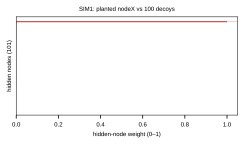

In [ ]:
fig, ax = plt.subplots(
    figsize=(3.4, 2.0),
    facecolor="none",
)
order = ranked.sort_values("weight")
colors = ["#b22222" if name == "nodeX" else "0.65" for name in order["node"]]
ax.barh(
    np.arange(len(order)),
    order["weight"].to_numpy(),
    color=colors,
    height=1.0,
)
ax.axhline(
    int(order["node"].tolist().index("nodeX")),
    color="#b22222",
    linewidth=0.4,
    alpha=0.5,
)
ax.set_yticks([])
ax.set_xlim(0, 1.05)
ax.set_xlabel("hidden-node weight (0–1)")
ax.set_ylabel("hidden nodes (101)")
ax.set_title("SIM1: planted nodeX vs 100 decoys")
ax.set_facecolor("none")
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(0.5)
fig.tight_layout()
plt.show()

`nodeX` (red) sits at 1. The 100 decoys sit near 0. That is
Figure 3a with `kpnn2` wiring: the named edgelist is the
architecture, and only the planted hidden node keeps a node
weight.
